# One flight, end to end

This notebook walks through what the pipeline does to a single Rongowai L1 file:
read it, keep the DDMs that pass the quality filters, label them, look at a few of
them, grow the peak region, compute the feature groups and draw the per-flight sample.
Everything here is the same code the scripts use (`src/rongowai_ddm`).

In [1]:
import sys, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, str(Path.cwd().parent / "src"))
from rongowai_ddm.config import Config
from rongowai_ddm.netcdf import read_flight, ANT_LHCP, ANT_RHCP
from rongowai_ddm.data.quality import quality_mask, slant_range_m
from rongowai_ddm.data.labels import binary_label, SURFACE_TYPE_NAMES
from rongowai_ddm.data.sampling import sample_reflections
from rongowai_ddm.features.layout import normalize_sum
from rongowai_ddm.features.peak_region import grow_peak_region
from rongowai_ddm.features.registry import compute_ddm_features, FEATURE_GROUPS
from rongowai_ddm.features.polarimetric import pair_features, PAIR_FEATURE_NAMES
from rongowai_ddm.evaluation import plots
plots.setup_style()
cfg = Config.load(Path.cwd().parent / "configs" / "default.yaml")
files = sorted(glob.glob(str(cfg.data_dir / "*.nc")))
path = files[100]
print(len(files), "flights;", "using", Path(path).name)

7324 flights; using 20221110-080859_NZWN-NZNS_L1.nc


## Reading the file

`raw_counts` is `(epochs, 20 channels, 40 delay bins, 5 Doppler bins)`. Channels 0–9 receive the left-hand circular polarization, channels 10–19 the right-hand one, and channel `c` and `c + 10` track the same reflection.

In [2]:
fl = read_flight(path)
print("raw_counts", fl.raw_counts.shape, fl.raw_counts.dtype)
ant_mode = [int(np.bincount(fl.ddm_ant[:, c]).argmax()) for c in range(20)]
print("antenna per channel (2 = LHCP, 3 = RHCP):", ant_mode)
same_prn = (fl.prn[:, :10] == fl.prn[:, 10:])[fl.ddm_ant[:, :10] != 0].mean()
print(f"twin channels share the PRN in {same_prn:.1%} of the valid pairs")

raw_counts (1180, 20, 40, 5) uint32
antenna per channel (2 = LHCP, 3 = RHCP): [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
twin channels share the PRN in 100.0% of the valid pairs


## Quality filters and labels

In [3]:
q = quality_mask(fl, cfg.quality)
rng_m = slant_range_m(fl.ac_alt, fl.sp_alt, fl.sp_inc_angle)
print(f"DDMs passing gains >= 5 dBi, 2-10 km slant range, non-empty: {q.mean():.1%}")
label = binary_label(fl.surface_type[:, :10])
pair_ok = q[:, :10] & q[:, 10:] & (label >= 0)
st = pd.Series(fl.surface_type[:, :10][pair_ok]).map(lambda v: SURFACE_TYPE_NAMES.get(int(v), 'nan'))
print(st.value_counts().to_string())
print(f"\nvalid reflections: {pair_ok.sum():,}   water {int((pair_ok & (label==0)).sum()):,}   land {int((pair_ok & (label==1)).sum()):,}")

DDMs passing gains >= 5 dBi, 2-10 km slant range, non-empty: 55.9%
ocean           4705
forest          1456
shrub            273
grass            136
inland water      14
artificial        10

valid reflections: 6,594   water 4,719   land 1,875


## A few DDMs

Water reflections concentrate their energy in a sharp peak; land spreads it along delay (downwards in these images) and Doppler.

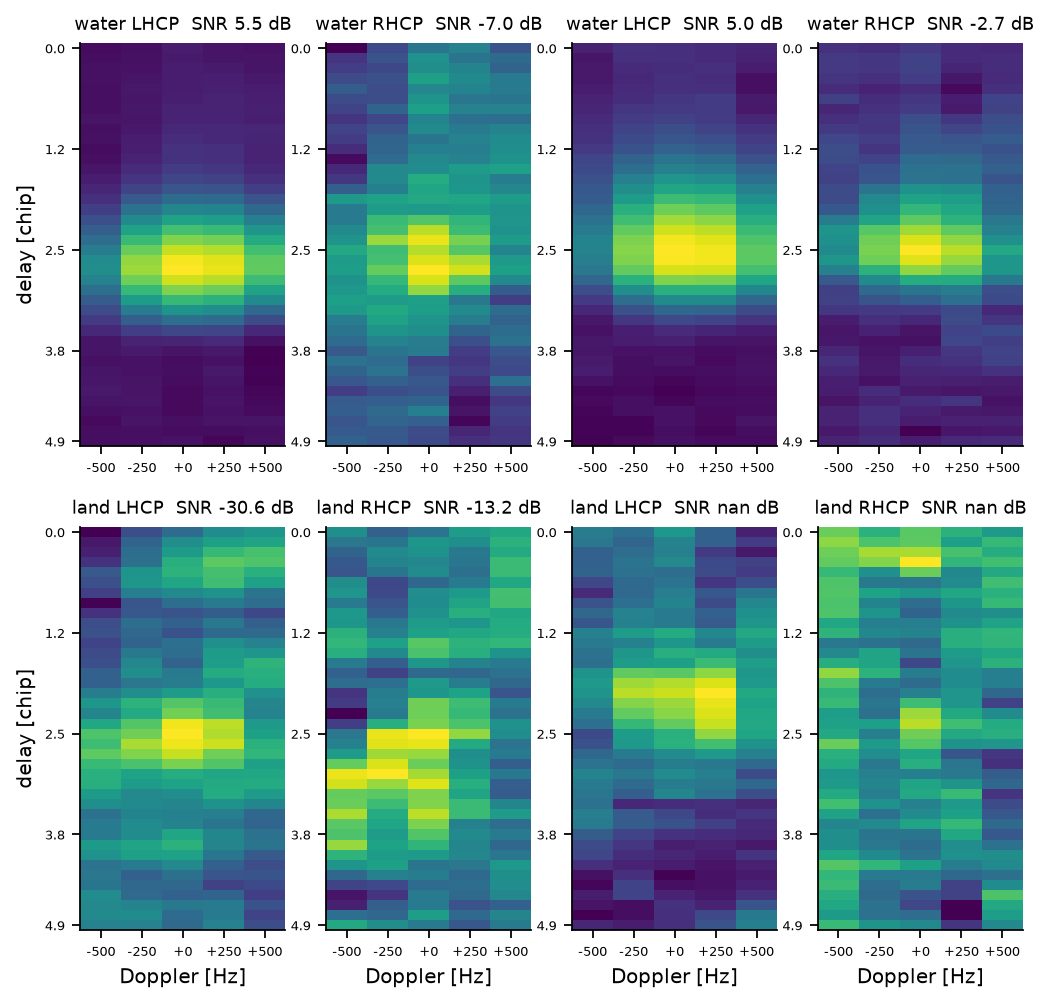

In [4]:
ep, ch = np.where(pair_ok)
rng = np.random.default_rng(0)
picks, titles = [], []
for lab, name in ((0, "water"), (1, "land")):
    idx = np.flatnonzero(label[ep, ch] == lab)
    for i in rng.choice(idx, 2, replace=False):
        for c_off, pol in ((0, "LHCP"), (10, "RHCP")):
            picks.append(fl.raw_counts[ep[i], ch[i] + c_off].astype(float))
            titles.append(f"{name} {pol}  SNR {fl.snr[ep[i], ch[i] + c_off]:.1f} dB")
plots.plot_ddm_gallery(np.stack(picks), titles, "/tmp/_gallery.png", ncols=4)
from IPython.display import Image; Image("/tmp/_gallery.png")

## The peak region

The region is grown from the brightest pixel by adding the brightest 8-connected neighbour until it holds 40 pixels. Its shape is one of the feature families.

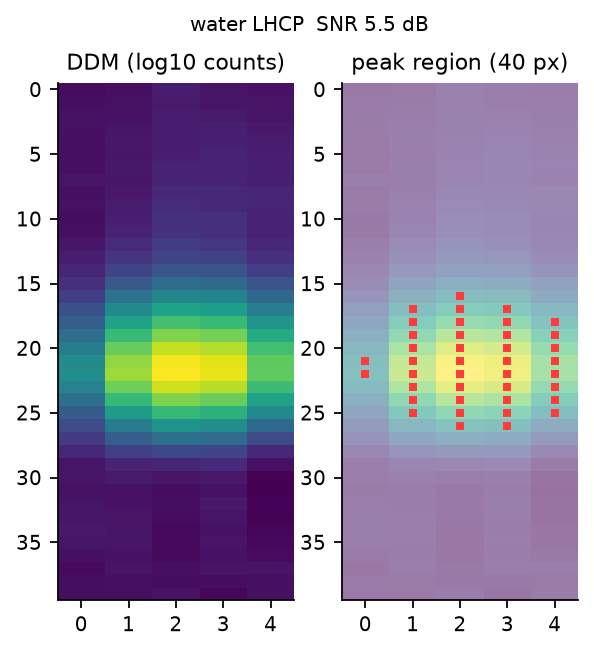

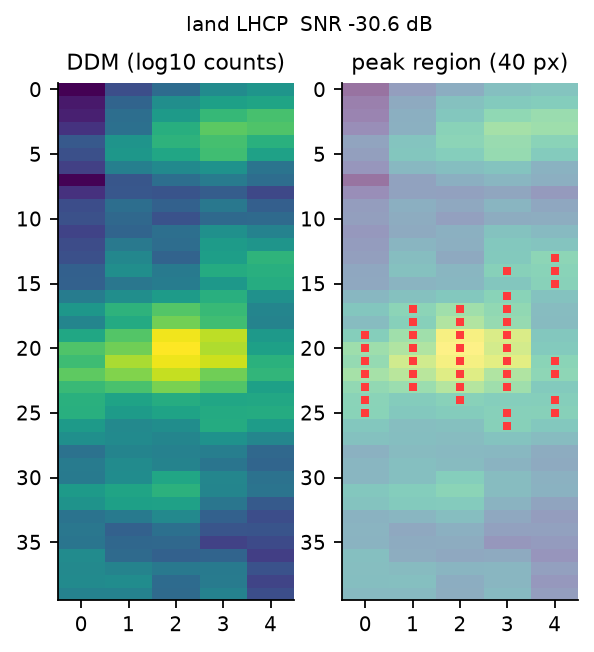

In [5]:
x = normalize_sum(np.stack(picks[:1] + picks[4:5]))
masks = grow_peak_region(x, cfg.features.peak_region_pixels)
plots.plot_peak_region(picks[0], masks[0], "/tmp/_peak_w.png", title=titles[0])
plots.plot_peak_region(picks[4], masks[1], "/tmp/_peak_l.png", title=titles[4])
from IPython.display import display
display(Image("/tmp/_peak_w.png"), Image("/tmp/_peak_l.png"))

## Feature groups on the sampled reflections

In [6]:
ep_s, ch_s = sample_reflections(pair_ok, label, cfg.sampling.max_reflections_per_flight, np.random.default_rng(cfg.sampling.seed))
raw_l = fl.raw_counts[ep_s, ch_s].astype(float); raw_r = fl.raw_counts[ep_s, ch_s + 10].astype(float)
feats = compute_ddm_features(raw_l, fl.noise_floor[ep_s, ch_s], cfg.features.peak_region_pixels)
feats_r = compute_ddm_features(raw_r, fl.noise_floor[ep_s, ch_s + 10], cfg.features.peak_region_pixels)
i_phpr = FEATURE_GROUPS["coherence"].index("phpr_db"); i_ent = FEATURE_GROUPS["coherence"].index("shannon_entropy")
pair = pair_features(raw_l, raw_r, fl.noise_floor[ep_s, ch_s], fl.noise_floor[ep_s, ch_s + 10], fl.snr[ep_s, ch_s], fl.snr[ep_s, ch_s + 10],
                     feats["coherence"][:, i_phpr], feats_r["coherence"][:, i_phpr], feats["coherence"][:, i_ent], feats_r["coherence"][:, i_ent])
table = pd.DataFrame(np.concatenate([feats[g] for g in ("global", "peak", "coherence", "power")] + [pair], axis=1),
                     columns=sum((list(FEATURE_GROUPS[g]) for g in ("global", "peak", "coherence", "power")), []) + list(PAIR_FEATURE_NAMES))
table["label"] = label[ep_s, ch_s]
print({g: feats[g].shape[1] for g in feats}, "+", len(PAIR_FEATURE_NAMES), "pair features")
show = ["phpr_db", "delay_width_hm", "vn_entropy", "wf_rmsd_ambiguity", "peak_energy_fraction", "count_snr_db", "pol_peak_ratio_db", "pol_shape_corr"]
table.groupby("label")[show].agg(["mean", "std"]).T.round(3)

{'global': 45, 'quadrant': 16, 'peak': 49, 'coherence': 16, 'power': 4} + 6 pair features


label                           0          1
phpr_db              mean  -4.895  -8.815000
                     std    1.307   1.246000
delay_width_hm       mean  13.320  38.626999
                     std    8.837   5.720000
vn_entropy           mean   0.041   0.011000
                     std    0.010   0.011000
wf_rmsd_ambiguity    mean   0.324   0.762000
                     std    0.114   0.136000
peak_energy_fraction mean   0.402   0.229000
                     std    0.070   0.035000
count_snr_db         mean   5.858  -7.760000
                     std    2.918   5.417000
pol_peak_ratio_db    mean   9.751   2.675000
                     std    3.626   4.925000
pol_shape_corr       mean   0.861   0.240000
                     std    0.163   0.279000

The polarimetric ratio alone already separates most of the two classes on this flight:

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
for lab, name in ((0, "water"), (1, "land")):
    ax.hist(table.loc[table.label == lab, "pol_peak_ratio_db"], bins=40, alpha=0.6, label=name, color=plots.COLORS[name])
ax.set(xlabel="LHCP / RHCP peak power ratio [dB]", ylabel="reflections"); ax.legend(); plt.show()

/tmp/ipykernel_417540/1113554450.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.set(xlabel="LHCP / RHCP peak power ratio [dB]", ylabel="reflections"); ax.legend(); plt.show()
